# Eigenvalues and Eigenvectors

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute eigenvalues and eigenvectors
- Interpret spectral properties of matrices
- Apply eigendecomposition to dimensionality reduction

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — you clustered 150 iris flowers there without ever asking which directions in the data carry the variance; eigenvectors answer that.

**Used later in:** Course 04 (AIAT 114) — Unit 4, lesson 03 "Principal Component Analysis (PCA)" — sklearn returns exactly these eigenvectors as its components.

---


---

## 📌 Real case: the eigenvector that ranked the web

In 1998 Sergey Brin and Larry Page described a search engine whose ranking signal was a single vector.
Model a random surfer who follows links and, with probability 1 − *d* (the **damping factor**,
conventionally **0.85**), jumps to a random page instead. The long-run fraction of time that surfer
spends on each page is exactly the **dominant eigenvector** of the web's link matrix, rescaled so each
column sums to one. That vector is PageRank. Brin and Page reported that on a link graph of
**322 million links** the computation converged to a usable tolerance in **52 iterations** of the power
method: the whole ranking of the early web, from one eigenvector of one enormous sparse matrix.

**What goes wrong without this.** Rank pages by counting inbound links and anyone can buy a top result
by creating a thousand pages that link to their own. The eigenvector answer is self-referential in a way
counting is not — a link from an important page counts more, and "important" is defined by the same
equation. That fixed point *is* what an eigenvector is, and it is why "solve for the eigenvector" was
worth building a company on.

**The same reasoning appears elsewhere:** citation ranking of scientific papers; identifying the most
structurally central account in a fraud ring; spectral clustering, which splits a graph using the
eigenvector of its Laplacian.


# Eigenvalues and Eigenvectors

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Vectors and Matrices Basics** - Understand matrices
- ✅ **Example 2: Matrix Operations** - Understand matrix multiplication
- ✅ **Basic understanding**: What are transformations?

**If you haven't completed these**, you might struggle with:
- Understanding eigenvalue decomposition
- Understanding why eigenvalues matter
- Using eigenvalues in ML applications

---

## 🔗 Where This Notebook Fits

**This is the THIRD example** - it uses concepts from Examples 1-2!

**Why this example THIRD?**
- **Before** you can understand eigenvalues, you need matrix operations (Example 2)
- **Before** you can do PCA, you need eigenvalues (Module 04)
- **Before** you can reduce dimensions, you need to find principal directions

**Builds on**: Examples 1-2 (matrices and operations)

**Leads to**: 
- 📓 Module 04: PCA (uses eigenvalue decomposition)
- 📓 Advanced ML: Dimensionality reduction techniques

---

## The Story: Understanding Before Using

Imagine you're analyzing a dataset. **Before** PCA, you have many features and don't know which matter most. **After** finding eigenvalues, you discover the most important directions in your data - the directions with most variance!

Same with machine learning: **Before** dimensionality reduction, we have high-dimensional data. **After** eigenvalue decomposition, we find the principal components that capture most information!

---

## Why This Concept Matters

### Why Eigenvalues/Eigenvectors Matter

**WHY** are eigenvalues and eigenvectors important?

1. **Dimensionality Reduction (PCA)**:
   - **WHY**: Reduce data dimensions while keeping information
   - **HOW**: Eigenvectors show directions of maximum variance
   - **AFTER**: Smaller datasets, faster training

2. **Data Understanding**:
   - **WHY**: Find most important directions in data
   - **HOW**: Eigenvalues show variance explained
   - **AFTER**: Better feature selection

3. **Matrix Decomposition**:
   - **WHY**: Understand matrix structure
   - **HOW**: Eigenvalue decomposition reveals properties
   - **AFTER**: Enables advanced ML techniques

## Learning Objectives
1. Compute eigenvalues and eigenvectors
2. Understand what they represent
3. See how they're used in PCA
4. Visualize principal directions
5. Understand variance explained
6. Apply to dimensionality reduction

---

## Step 1: Import necessary libraries

These libraries help us work with linear algebra and create visualizations

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: load the libraries this lesson relies on.
# NumPy computes eigenvalues/eigenvectors, the shared loader fetches the real dataset,
# and Matplotlib shows what the eigenvectors mean geometrically.

import numpy as np  # For linear algebra operations
import pandas as pd  # DataFrames - what the shared loader hands back
import matplotlib.pyplot as plt  # For creating plots and visualizations

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------------------------


# Confirm the environment is ready before any math starts.
print('✅ Libraries imported successfully!')
print('\n📚 What each library does:')
print('   - numpy: Linear algebra operations (vectors, matrices, math)')
print('   - pandas: DataFrames (the shared data loader returns one)')
print('   - matplotlib: Create plots and visualizations')


✅ Libraries imported successfully!

📚 What each library does:
   - numpy: Linear algebra operations (vectors, matrices, math)
   - pandas: DataFrames (the shared data loader returns one)
   - matplotlib: Create plots and visualizations


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this concept works in ML!

**Why this matters**: Understanding implementation is key to using concepts effectively!

## Step 1: Computing Eigenvalues and Eigenvectors

**BEFORE**: We have a covariance matrix but don't know the important directions.

**AFTER**: We'll compute eigenvalues and eigenvectors to find directions of maximum variance!

**Why eigenvalues?** They tell us which directions in the data contain the most information!

---

### 📖 Quick recap: variance, covariance, and the covariance matrix

(Formally taught in Unit 3, notebook 03 — here is the minimum you need now.)

- **Variance** of a feature x: the average squared distance from its mean, Var(x) = mean((x − x̄)²). It measures how spread out the feature is.
- **Covariance** of two features x and y: Cov(x, y) = mean((x − x̄)(y − ȳ)). Positive → they rise together; negative → one rises as the other falls; near 0 → unrelated.
- **Covariance matrix** for 2 features — a 2×2 matrix collecting all of these:

  |       | x         | y         |
  |-------|-----------|-----------|
  | **x** | Var(x)    | Cov(x, y) |
  | **y** | Cov(x, y) | Var(y)    |

`np.cov(data.T)` computes exactly this matrix. The eigen-analysis below then asks: *in which directions does this data actually spread?*

In [2]:
# Example 1: Computing Eigenvalues and Eigenvectors on REAL data
# WHY: Find the principal directions in a real feature matrix
# HOW: Eigenvalue decomposition of the covariance matrix
#
# Dataset: USArrests - violent-crime rates recorded for all 50 US states (1973),
# expressed as arrests per 100,000 residents. This is the dataset PCA is classically
# taught on, and every number in it was actually measured.

arrests = load("crime_statistics_original_50")
feature_names = ["Murder", "Assault"]

print("Dataset: USArrests (arrests per 100,000 residents, 50 US states)")
print(arrests[["State"] + feature_names].head())
print(f"\nThe two features live on very different scales -> "
      f"Murder spans {arrests['Murder'].min():.1f}-{arrests['Murder'].max():.1f}, "
      f"Assault spans {arrests['Assault'].min()}-{arrests['Assault'].max()}")

# Standardize each feature (subtract the mean, divide by the standard deviation).
# WHY this matters: Assault is counted in the hundreds while Murder is in the teens.
# On the raw numbers the covariance matrix would just report that Assault has the
# bigger units, and PCA would describe the measuring stick instead of the structure.
raw = arrests[feature_names].to_numpy(dtype=float)
data = (raw - raw.mean(axis=0)) / raw.std(axis=0, ddof=1)

# Compute covariance matrix (shows how features vary together)
cov_matrix = np.cov(data.T)

# Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nExample 1: Eigenvalue Decomposition")
print("=" * 60)
print(f"Standardized data shape: {data.shape}  ({data.shape[0]} states, {data.shape[1]} features)")
print("Covariance matrix (equals the correlation matrix, because the data is standardized):")
print(cov_matrix)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")
print("\n💡 WHY: Eigenvalues show how much variance each direction explains!")
print("💡 HOW: Larger eigenvalue = more variance in that direction!")


crime_statistics_original_50: full file, 50 rows.
Dataset: USArrests (arrests per 100,000 residents, 50 US states)
        State  Murder  Assault
0     Alabama    13.2      236
1      Alaska    10.0      263
2     Arizona     8.1      294
3    Arkansas     8.8      190
4  California     9.0      276

The two features live on very different scales -> Murder spans 0.8-17.4, Assault spans 45-337

Example 1: Eigenvalue Decomposition
Standardized data shape: (50, 2)  (50 states, 2 features)
Covariance matrix (equals the correlation matrix, because the data is standardized):
[[1.         0.80187331]
 [0.80187331 1.        ]]

Eigenvalues: [0.19812669 1.80187331]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]

💡 WHY: Eigenvalues show how much variance each direction explains!
💡 HOW: Larger eigenvalue = more variance in that direction!


## Step 2: Understanding Results

**BEFORE**: We computed eigenvalues but don't know what they mean.

**AFTER**: We'll interpret eigenvalues to understand which directions matter most!

**Why interpretation?** We need to know which components to keep for dimensionality reduction!

In [3]:
# Example 2: Understanding Eigenvalues
# WHY: Know which directions matter
# HOW: Larger eigenvalues = more variance

# Sort by eigenvalue (largest first)
idx = eigenvalues.argsort()[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

# Eigenvectors are only defined up to a sign flip: if v is an eigenvector, so is -v.
# Fix a convention so the arrows and the state ranking below read naturally -
# make each component's largest entry positive, so "higher score = higher crime rate".
for j in range(eigenvectors_sorted.shape[1]):
    if eigenvectors_sorted[np.argmax(np.abs(eigenvectors_sorted[:, j])), j] < 0:
        eigenvectors_sorted[:, j] *= -1

# Calculate variance explained
total_variance = eigenvalues_sorted.sum()
variance_explained = eigenvalues_sorted / total_variance * 100

print("\nExample 2: Variance Explained by Each Component")
print("=" * 60)
for i, (val, var) in enumerate(zip(eigenvalues_sorted, variance_explained)):
    print(f"Component {i+1}:")
    print(f"  - Eigenvalue: {val:.4f}")
    print(f"  - Variance explained: {var:.2f}%")
    print(f"  - Eigenvector: {eigenvectors_sorted[:, i]}")
print(f"\n💡 WHY: This tells us which components to keep!")
print(f"💡 HOW: Keep components with highest variance explained!")


Example 2: Variance Explained by Each Component
Component 1:
  - Eigenvalue: 1.8019
  - Variance explained: 90.09%
  - Eigenvector: [0.70710678 0.70710678]
Component 2:
  - Eigenvalue: 0.1981
  - Variance explained: 9.91%
  - Eigenvector: [ 0.70710678 -0.70710678]

💡 WHY: This tells us which components to keep!
💡 HOW: Keep components with highest variance explained!


## Step 3: Application to PCA

**BEFORE**: We have high-dimensional data with many features.

**AFTER**: We'll use eigenvalues to reduce dimensions while keeping most information!

**Why PCA?** It uses eigenvalues to find the most important directions and project data onto them!

In [4]:
# Example 3: PCA Application
# WHY: Reduce dimensions efficiently
# HOW: Use top k eigenvectors (principal components)

# Select top component (largest eigenvalue)
top_component = eigenvectors_sorted[:, 0]  # First principal component

# Project data onto principal component
data_projected = data @ top_component

print("\nExample 3: Dimensionality Reduction with PCA")
print("=" * 60)
print(f"Original data shape: {data.shape} ({data.shape[0]} states, {data.shape[1]} features)")
print(f"Projected data shape: {data_projected.shape} ({data_projected.shape[0]} states, 1 feature)")
print(f"\nVariance kept: {variance_explained[0]:.2f}%")
print(f"\n💡 WHY: Reduced from 2D to 1D while keeping {variance_explained[0]:.2f}% of variance!")
print(f"💡 HOW: Projected data onto direction of maximum variance!")
print("💡 MEANING: because murder and assault rates rise and fall together across states,")
print("   PC1 acts as a single 'violent-crime level' score for each state.")

# Rank the states along that one combined axis.
order = np.argsort(data_projected)
print(f"\nLowest on PC1:  {', '.join(arrests['State'].iloc[order[:5]])}")
print(f"Highest on PC1: {', '.join(arrests['State'].iloc[order[-5:][::-1]])}")



Example 3: Dimensionality Reduction with PCA
Original data shape: (50, 2) (50 states, 2 features)
Projected data shape: (50,) (50 states, 1 feature)

Variance kept: 90.09%

💡 WHY: Reduced from 2D to 1D while keeping 90.09% of variance!
💡 HOW: Projected data onto direction of maximum variance!
💡 MEANING: because murder and assault rates rise and fall together across states,
   PC1 acts as a single 'violent-crime level' score for each state.

Lowest on PC1:  North Dakota, Vermont, New Hampshire, Iowa, Wisconsin
Highest on PC1: Florida, North Carolina, Mississippi, South Carolina, Georgia


### 🧪 Does standardizing before PCA change the answer?

Baseline: eigen-decompose the covariance matrix of the **raw** arrests-per-100,000 numbers.
Change one thing: standardize both features first — which is what the cells above quietly did.
Measure: where the first principal component points, and how much variance it claims.

In [5]:
# Comparative experiment: raw covariance vs standardized covariance, same 50 states.

raw_features = arrests[feature_names].to_numpy(dtype=float)                 # untouched units
std_features = (raw_features - raw_features.mean(axis=0)) / raw_features.std(axis=0)

for label, M in [("RAW units (arrests per 100,000)", raw_features),
                 ("STANDARDIZED (each feature mean 0, std 1)", std_features)]:
    cov = np.cov(M, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)          # eigh: a covariance matrix is symmetric
    order = vals.argsort()[::-1]              # largest eigenvalue first
    vals, vecs = vals[order], vecs[:, order]
    if vecs[np.argmax(np.abs(vecs[:, 0])), 0] < 0:
        vecs[:, 0] *= -1                      # fix the sign so the loadings read naturally
    print(label)
    print(f"   feature variances : {feature_names[0]}={cov[0, 0]:9.2f}   {feature_names[1]}={cov[1, 1]:9.2f}")
    print(f"   PC1 direction     : {vecs[0, 0]:+.3f} x {feature_names[0]}   {vecs[1, 0]:+.3f} x {feature_names[1]}")
    print(f"   variance explained by PC1: {100 * vals[0] / vals.sum():.2f}%")
    print()

print("Conclusion the numbers support: on the raw scale Assault's variance is hundreds of times")
print("Murder's, so PC1 lines up almost exactly with the Assault axis and reports a")
print("variance-explained figure that LOOKS spectacular. It is measuring the choice of units, not")
print("a pattern in crime. Standardizing first is what turns PC1 into a statement about the two")
print("crimes rather than about the size of the numbers used to record them.")

RAW units (arrests per 100,000)
   feature variances : Murder=    18.97   Assault=  6945.17
   PC1 direction     : +0.042 x Murder   +0.999 x Assault
   variance explained by PC1: 99.90%

STANDARDIZED (each feature mean 0, std 1)
   feature variances : Murder=     1.02   Assault=     1.02
   PC1 direction     : +0.707 x Murder   +0.707 x Assault
   variance explained by PC1: 90.09%

Conclusion the numbers support: on the raw scale Assault's variance is hundreds of times
Murder's, so PC1 lines up almost exactly with the Assault axis and reports a
variance-explained figure that LOOKS spectacular. It is measuring the choice of units, not
a pattern in crime. Standardizing first is what turns PC1 into a statement about the two
crimes rather than about the size of the numbers used to record them.


---

## 📊 Visualization: where does "the main direction" actually point?

The experiment above returned two different first principal components for the same 50 states —
`+0.042×Murder +0.999×Assault` on the raw numbers, `+0.707×Murder +0.707×Assault` after standardizing.
Numbers like that are easy to nod at and hard to feel. Both are drawn below, on the same states.

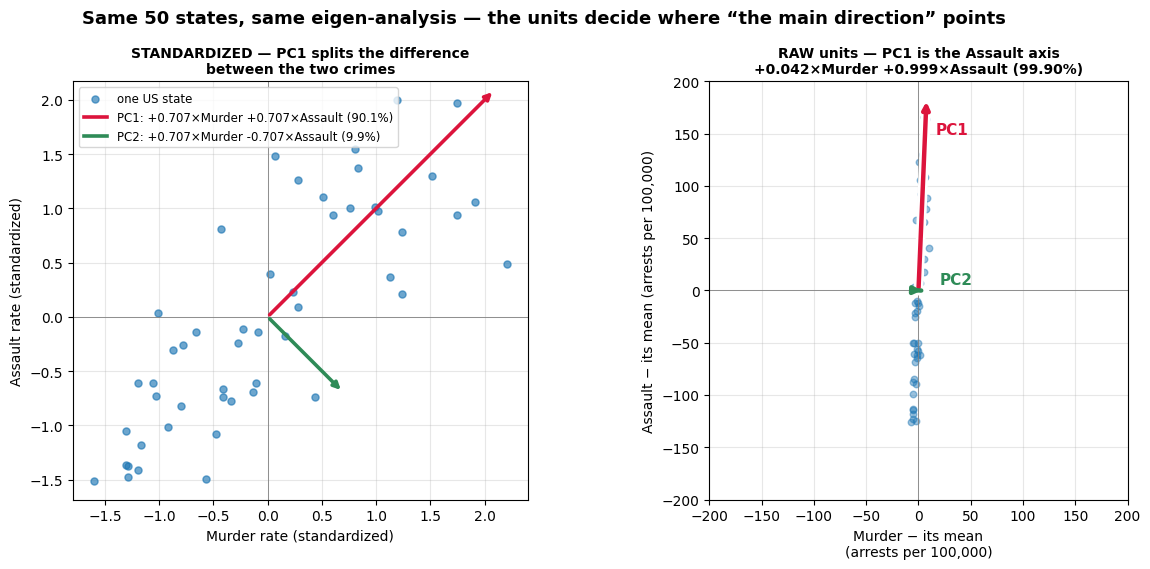

Reading the figure:
  - Left, PC1 arrow is 3.0x longer than PC2's, because arrow length is the
    standard deviation along that direction: sqrt(1.802) against sqrt(0.198).
  - Left, the arrow sits at 45 degrees: PC1 weights Murder and Assault equally. It is a
    'how violent is this state overall' score, and it carries 90.1% of the variance.
  - Right, the same 50 states in arrests per 100,000, both axes on the SAME scale. The cloud
    is a vertical smear because Assault spans about 290 units and Murder about 17.
  - Right, PC1 therefore points almost straight up: 99.8% of it is the Assault axis,
    and it claims 99.90% of the variance - a number that describes the
    measuring stick, not the crime.


In [6]:
# The lesson's core claim, drawn: an eigenvector points along the direction the data actually spreads,
# and "the data" means the numbers AS RECORDED - so the units choose the direction.
# WHY two panels: same 50 states, same eigen-decomposition, one before and one after standardizing.
# HOW to read an arrow: its direction is the eigenvector; its LENGTH is proportional to the square root
#      of its eigenvalue, i.e. to the standard deviation of the data along that direction.
# NOTE: both panels use equal aspect, so an angle on the page is a real angle in the data. In the right
#       panel both axes are counted in the same unit (arrests per 100,000), which is what makes the
#       vertical smear an honest picture rather than a plotting artefact.

import numpy as np
import matplotlib.pyplot as plt


def principal_components(M):
    """Eigen-decompose the covariance matrix of M; return eigenvalues and eigenvectors, largest first."""
    cov = np.cov(M, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)              # eigh: covariance matrices are symmetric
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    for j in range(vecs.shape[1]):                # fix the sign so "more crime" points up and right
        if vecs[np.argmax(np.abs(vecs[:, j])), j] < 0:
            vecs[:, j] *= -1
    return vals, vecs


raw_units = arrests[feature_names].to_numpy(dtype=float)
std_units = (raw_units - raw_units.mean(axis=0)) / raw_units.std(axis=0, ddof=1)
vals_std, vecs_std = principal_components(std_units)
vals_raw, vecs_raw = principal_components(raw_units)
arrow_colours = ["crimson", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6), gridspec_kw={"width_ratios": [1.5, 1]})

# Panel 1: after standardizing - the version every cell above this one used.
ax = axes[0]
ax.scatter(std_units[:, 0], std_units[:, 1], s=26, alpha=0.65, color="tab:blue",
           label="one US state", zorder=2)
for j in range(2):
    tip = vecs_std[:, j] * np.sqrt(vals_std[j]) * 2.2      # length ∝ spread along that direction
    ax.annotate("", xy=(tip[0], tip[1]), xytext=(0, 0), zorder=6, annotation_clip=False,
                arrowprops=dict(arrowstyle="-|>", lw=2.6, color=arrow_colours[j], zorder=10))
    ax.plot([], [], color=arrow_colours[j], lw=2.6,
            label=f"PC{j+1}: {vecs_std[0, j]:+.3f}\u00d7Murder {vecs_std[1, j]:+.3f}\u00d7Assault "
                  f"({100 * vals_std[j] / vals_std.sum():.1f}%)")
ax.set_xlabel("Murder rate (standardized)")
ax.set_ylabel("Assault rate (standardized)")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8.5, loc="upper left")
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_title("STANDARDIZED \u2014 PC1 splits the difference\nbetween the two crimes",
             fontsize=10, fontweight="bold")

# Panel 2: the SAME states in the units they were recorded in, mean-centred so the arrows start at 0.
ax = axes[1]
centred = raw_units - raw_units.mean(axis=0)
ax.scatter(centred[:, 0], centred[:, 1], s=22, alpha=0.45, color="tab:blue", zorder=2)
for j in range(2):
    tip = vecs_raw[:, j] * np.sqrt(vals_raw[j]) * 2.2
    # PC1 runs straight through the middle of the point cloud, so lay a white halo under it first -
    # otherwise the arrow that carries the whole message is buried in the dots.
    ax.plot([0, tip[0]], [0, tip[1]], color="white", lw=7, solid_capstyle="round", zorder=5)
    ax.annotate("", xy=(tip[0], tip[1]), xytext=(0, 0), zorder=6, annotation_clip=False,
                arrowprops=dict(arrowstyle="-|>", lw=3.2, color=arrow_colours[j], zorder=10))
ax.text(16, 150, "PC1", color="crimson", fontweight="bold", fontsize=11)
ax.text(20, 6, "PC2", color="seagreen", fontweight="bold", fontsize=11)
limit = 200
ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit); ax.set_aspect("equal")
ax.set_xlabel("Murder \u2212 its mean\n(arrests per 100,000)")
ax.set_ylabel("Assault \u2212 its mean (arrests per 100,000)")
ax.grid(alpha=0.3); ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_title(f"RAW units \u2014 PC1 is the Assault axis\n"
             f"{vecs_raw[0, 0]:+.3f}\u00d7Murder {vecs_raw[1, 0]:+.3f}\u00d7Assault "
             f"({100 * vals_raw[0] / vals_raw.sum():.2f}%)", fontsize=10, fontweight="bold")

fig.suptitle("Same 50 states, same eigen-analysis \u2014 the units decide where \u201cthe main direction\u201d points",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Reading the figure:")
print("=" * 68)
print(f"  - Left, PC1 arrow is {np.sqrt(vals_std[0] / vals_std[1]):.1f}x longer than PC2's, because arrow length is the")
print(f"    standard deviation along that direction: sqrt({vals_std[0]:.3f}) against sqrt({vals_std[1]:.3f}).")
print("  - Left, the arrow sits at 45 degrees: PC1 weights Murder and Assault equally. It is a")
print("    'how violent is this state overall' score, and it carries "
      f"{100 * vals_std[0] / vals_std.sum():.1f}% of the variance.")
print("  - Right, the same 50 states in arrests per 100,000, both axes on the SAME scale. The cloud")
print("    is a vertical smear because Assault spans about 290 units and Murder about 17.")
print(f"  - Right, PC1 therefore points almost straight up: {100 * vecs_raw[1, 0] ** 2:.1f}% of it is the Assault axis,")
print(f"    and it claims {100 * vals_raw[0] / vals_raw.sum():.2f}% of the variance - a number that describes the")
print("    measuring stick, not the crime.")


**What to look for in the figure above.** The blue dots are the same 50 states in both panels. Only the
units changed.

*Left (standardized).* The cloud leans up and to the right — states with more murder tend to have more
assault — and the crimson PC1 arrow lies straight along that lean, at 45°, weighting the two crimes
equally (`+0.707 / +0.707`). The green PC2 arrow is perpendicular to it and about **three times shorter**,
because arrow length is drawn proportional to the standard deviation along that direction, and
1.80 against 0.198 in eigenvalue is 3.0 in standard deviation. That ratio *is* the 90% / 10% split of
the variance.

*Right (raw units).* Both axes now count arrests per 100,000 and are drawn at the same scale, so the
picture is fair: the states form an almost vertical smear, because assault rates spread over roughly
290 units while murder rates spread over about 17. The crimson PC1 arrow runs straight up the middle
of that smear — it is the Assault column with a new name (`+0.999` of it), and it reports 99.90% of
the variance explained. Nothing is wrong with the arithmetic. It answered the question you asked, which
on raw numbers was "which column has the biggest numbers".

The green PC2 arrow in the right panel is the short stub at the origin: on this scale the entire
murder-rate structure of the United States is a few pixels wide.

### 🎬 Step storyboard: where does an eigenvector come from?

`np.linalg.eig` returns eigenvectors in one call, which makes them look like something the computer
already knew. It did not. The oldest algorithm for finding one is three lines long and you can watch it
work: **take any vector, multiply it by the matrix, rescale it back to length 1, and repeat.** Each
multiplication stretches the vector more along the directions the matrix stretches most, so the direction
that survives is the one it stretches *hardest* — which is the definition of the top eigenvector.

Below, the starting vector is deliberately chosen to point almost the wrong way, nearly along PC2. Watch
the six frames left to right.

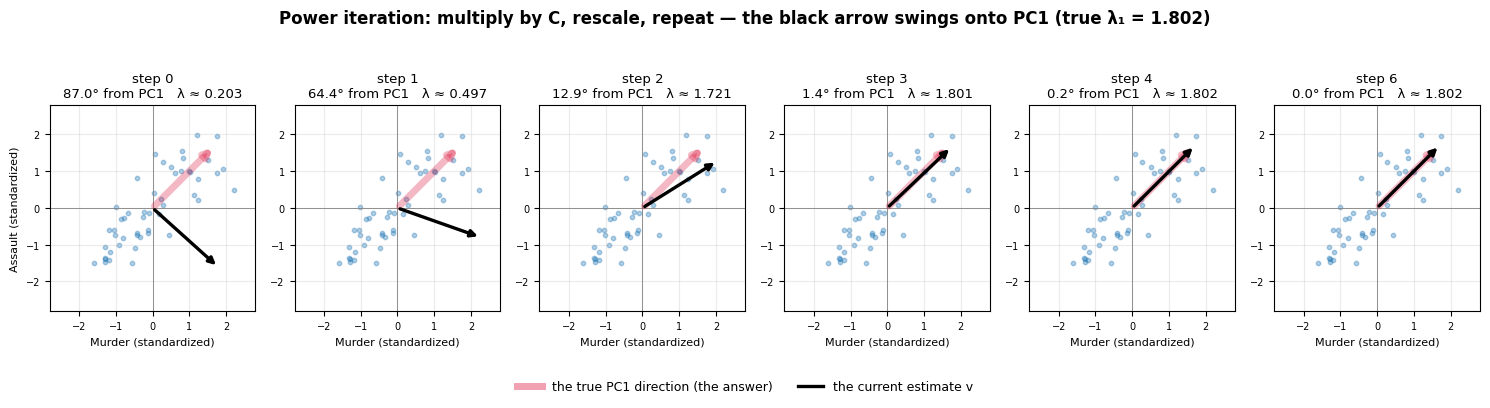

step | angle to PC1 |    λ estimate (vᵀ C v) |   error in λ
--------------------------------------------------------------
   0 |       86.99° |                0.20256 |     1.60e+00
   1 |       64.42° |                0.49708 |     1.30e+00
   2 |       12.94° |                1.72149 |     8.04e-02
   3 |        1.45° |                1.80085 |     1.02e-03
   4 |        0.16° |                1.80186 |     1.24e-05
   5 |        0.02° |                1.80187 |     1.50e-07
   6 |        0.00° |                1.80187 |     1.81e-09

Ratio of the two eigenvalues: λ₁/λ₂ = 9.1.
That ratio is the convergence rate: every step multiplies the leftover PC2 component by
1/9.1, which is why four steps were enough here. When two eigenvalues are
close, the same algorithm crawls - and that is the honest limit of this method.


In [7]:
# Frame-grid storyboard: power iteration on the covariance matrix of the same 50 US states.
# WHY: this is how eigenvectors are actually obtained on matrices too big to decompose - and it turns
#      "eigenvector" from a definition into something you can see happen.
# HOW: v <- C v, then v <- v / ||v||, repeated. The estimate of the eigenvalue at each step is the
#      Rayleigh quotient v^T C v, which for a unit vector is the variance of the data along v.
# NOTE: the starting vector is fixed, not random - (1, -0.9), deliberately close to PC2, so the swing
#       is worth watching. Any starting vector works as long as it is not exactly perpendicular to PC1.

import numpy as np
import matplotlib.pyplot as plt

C = cov_matrix                                   # the 2x2 covariance matrix computed earlier
pc1_true = eigenvectors_sorted[:, 0]             # the answer, for reference only
lambda1_true = eigenvalues_sorted[0]

v = np.array([1.0, -0.9])
v = v / np.linalg.norm(v)                        # step 0: a unit vector pointing almost along PC2
frames = [0, 1, 2, 3, 4, 6]                      # which steps to draw

history = {}
v_k = v.copy()
for k in range(max(frames) + 1):
    if k in frames:
        history[k] = v_k.copy()
    v_k = C @ v_k                                # the whole algorithm: multiply...
    v_k = v_k / np.linalg.norm(v_k)              # ...and rescale to length 1

fig, axes = plt.subplots(1, len(frames), figsize=(15, 3.8))
for ax, k in zip(axes, frames):
    v_show = history[k]
    if v_show @ pc1_true < 0:                    # a vector and its negative are the same direction
        v_show = -v_show
    angle = np.degrees(np.arccos(np.clip(abs(v_show @ pc1_true), -1, 1)))
    rayleigh = v_show @ C @ v_show               # the eigenvalue estimate at this step
    ax.scatter(data[:, 0], data[:, 1], s=10, alpha=0.35, color="tab:blue", zorder=1)
    ax.annotate("", xy=tuple(pc1_true * 2.4), xytext=(0, 0), annotation_clip=False,
                arrowprops=dict(arrowstyle="-|>", lw=5, color="crimson", alpha=0.3, zorder=4))
    ax.annotate("", xy=tuple(v_show * 2.4), xytext=(0, 0), annotation_clip=False,
                arrowprops=dict(arrowstyle="-|>", lw=2.4, color="black", zorder=6))
    ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8); ax.set_aspect("equal")
    ax.grid(alpha=0.25); ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
    ax.set_title(f"step {k}\n{angle:.1f}\u00b0 from PC1   \u03bb \u2248 {rayleigh:.3f}", fontsize=9.5)
    ax.set_xlabel("Murder (standardized)", fontsize=8); ax.tick_params(labelsize=7)
axes[0].set_ylabel("Assault (standardized)", fontsize=8)

proxy_true, = axes[0].plot([], [], color="crimson", lw=5, alpha=0.4)
proxy_est, = axes[0].plot([], [], color="black", lw=2.4)
fig.legend([proxy_true, proxy_est],
           ["the true PC1 direction (the answer)", "the current estimate v"],
           loc="lower center", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f"Power iteration: multiply by C, rescale, repeat \u2014 the black arrow swings onto PC1 "
             f"(true \u03bb\u2081 = {lambda1_true:.3f})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# The step table behind the storyboard - every step, not only the six that were drawn.
print(f"{'step':>4} | {'angle to PC1':>12} | {'\u03bb estimate (v\u1d40 C v)':>22} | {'error in \u03bb':>12}")
print("-" * 62)
v_k = v.copy()
for k in range(7):
    v_show = v_k if v_k @ pc1_true >= 0 else -v_k
    angle = np.degrees(np.arccos(np.clip(abs(v_show @ pc1_true), -1, 1)))
    rayleigh = v_show @ C @ v_show
    print(f"{k:>4} | {angle:>11.2f}\u00b0 | {rayleigh:>22.5f} | {lambda1_true - rayleigh:>12.2e}")
    v_k = C @ v_k
    v_k = v_k / np.linalg.norm(v_k)
print()
print(f"Ratio of the two eigenvalues: \u03bb\u2081/\u03bb\u2082 = {eigenvalues_sorted[0] / eigenvalues_sorted[1]:.1f}.")
print("That ratio is the convergence rate: every step multiplies the leftover PC2 component by")
print(f"1/{eigenvalues_sorted[0] / eigenvalues_sorted[1]:.1f}, which is why four steps were enough here. When two eigenvalues are")
print("close, the same algorithm crawls - and that is the honest limit of this method.")


**What to look for in the storyboard above.** All six panels show the same 50 states and the same faint
red arrow — the true first principal component, drawn for reference. The black arrow is the running
estimate, and it is the only thing that changes.

At **step 0** the black arrow points down and to the right, 87° away from the answer: it was chosen to
start almost perpendicular to PC1, which is nearly the worst possible guess. Its eigenvalue estimate is
0.203 — close to λ₂, because that is very nearly the direction it is pointing. One multiplication by the
covariance matrix takes it to 64°, the next to 13°, and by **step 3** it is within 1.5° of the answer and
its λ estimate is 1.801 against the true 1.802. From step 3 on, the black arrow lies on top of the red one
and only a pink fringe around its edges is still visible.

Two things worth taking away. First, an eigenvector is not something the computer looks up; it is the
direction that survives repeated multiplication, and this is what "survives" looks like. Second, the
λ estimate converges *much* faster than the direction does — at step 2 the arrow is still 13° off but the
eigenvalue is already right to two decimals. That is a general property of the Rayleigh quotient, and it
is why large-scale eigensolvers report eigenvalues confidently long before their vectors have settled.

---

## ⚠️ Where this breaks

- **Eigen-directions follow units, not importance.** The comparison above is the whole warning. On the
  raw scale the first principal component is essentially the Assault column wearing a new name, and it
  reports a variance-explained figure so high it looks like a triumph. The arithmetic is not wrong — the
  covariance matrix genuinely is dominated by the feature with the biggest numbers. The assumption that
  must hold before you read a component as "the main pattern in the data" is that the features were put
  on a common scale first.
- **Real eigenvalues require a symmetric matrix.** Covariance matrices are symmetric, so we are safe here.
  Applied to a general transformation — a rotation, a Markov transition matrix — eigenvalues can be
  complex and there is no real "direction of maximum variance" to find at all. (Notebook 00 of this unit
  prints exactly that case.)
- **Variance is not information.** PC1 here carries most of the variance in two crime rates. That does not
  make it the useful direction for every question: if you wanted to know which states *changed* most
  between census years, the low-variance direction may hold the signal. Cheaper alternative when you
  already know which columns matter: select them (Unit 4, notebook 03) instead of rotating everything.


---

## 💬 Discuss

1. PageRank decides which page a billion people see first, and it is one eigenvector with one tunable
   constant. Who should be allowed to change the damping factor from 0.85, and what evidence would
   justify the change? Would you answer differently for a Saudi government portal's internal search?
2. The raw-versus-standardized experiment produces two different "most important directions" for the same
   50 states. Which one belongs in a report to a state governor — and how do you explain to them that the
   other one exists?
3. This notebook compresses each state from two crime measures into one number and prints how much
   variance survived. If a journalist asked "so which state is worst?", is that single number an honest
   answer? Name precisely what it hides.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding eigenvalues/eigenvectors:

1. **PCA Implementation**: Ready for Module 04
2. **Feature Selection**: Can identify important features
3. **Data Compression**: Can reduce data size
4. **Dimensionality Reduction**: Can work with high-dimensional data

**Next Steps**:
   - Apply to PCA in Module 04
   - Use for feature selection
   - Apply to real ML problems

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to implement this concept.

**AFTER this notebook**: We can:
- ✅ Understand WHY this concept matters
- ✅ Implement HOW it works
- ✅ See what happens AFTER (results and implications)
- ✅ Apply it to real ML scenarios

**Next Steps**: 
- 📓 Review other examples in this module
- 📓 Complete exercises
- 📓 Move to next module

---

## ✅ Example Complete!

You've learned this concept using the **Why → How → After** methodology!

**Key Takeaway**: Understanding WHY, HOW, and AFTER helps you master concepts deeply!

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 4: Matrix Decompositions. Cambridge University Press. <https://mml-book.github.io/>
3. Brin, S., & Page, L. (1998). *The Anatomy of a Large-Scale Hypertextual Web Search Engine*. Computer Networks and ISDN Systems, 30(1–7), 107–117.
4. Dereziński, M., & Mahoney, M. W. (2024). *Recent and Upcoming Developments in Randomized Numerical Linear Algebra for Machine Learning*. arXiv. <https://arxiv.org/abs/2406.11151> — how eigen- and SVD problems too large for `np.linalg.eig` are solved in practice: randomized sketching.
5. Zhu et al. (2025). *The Path Not Taken: RLVR Provably Learns Off the Principals*. arXiv. <https://arxiv.org/abs/2511.08567> — reading what training did to a model through the principal directions of its weight matrices.
